
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [1]:
import numpy as np

from datastructures import *
from training import *
from models import *
from residuals import *

/home/fmoller/miniforge3/envs/pygproj/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load all organoids
data_dir = "training_data"
graphs = load_dir_to_graphs(data_dir)
print(f"Loaded {len(graphs)} organoids.")

# Load metadata & attach
meta = load_aux_metadata_for_dir("training_data")
attached = attach_metadata_to_graphs(graphs, meta)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

Loaded 1215 graphs; skipped 0.
Loaded 1215 organoids.
Attached metadata to 1215/1215 graphs.


In [3]:

# (Optional) global outlier filtering BEFORE split (applies to all)
low_pct, high_pct = 0.0, 100.0   # example: keep middle 0–95th percentile
graphs, thr = filter_outliers(graphs, low_pct=low_pct, high_pct=high_pct, stat="median")
print(f"After global filter: {len(graphs)} organoids | thresholds: {thr}")

After global filter: 1215 organoids | thresholds: {'low': -0.0022743481677025557, 'high': 0.8184399008750916}


In [4]:
# graphs: list[Data] already loaded and with .meta attached
complexities = []
for g in graphs:
    md = getattr(g, "meta", {}) or {}
    v = md.get("complexity", np.nan)
    try:
        v = float(v)
    except Exception:
        v = np.nan
    complexities.append(v)

complexities = np.asarray(complexities, dtype=float)
mask_keep = np.isfinite(complexities) & (complexities >= -1.0)

kept_graphs    = [g for g, m in zip(graphs, mask_keep) if m]
dropped_graphs = [g for g, m in zip(graphs, mask_keep) if not m]

print(f"Complexity filter: kept {len(kept_graphs)} / {len(graphs)} | "
      f"dropped {len(dropped_graphs)} (missing/NaN or < 1)")

# replace your working list
graphs = kept_graphs

Complexity filter: kept 1182 / 1215 | dropped 33 (missing/NaN or < 1)


In [5]:
# Split dataset by organoid
g_train, g_val = split_graphs(graphs, val_frac=0.1, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")


center, scale = standardize_targets(g_train, g_val, robust=True)

Split -> train: 1064 | val: 118


In [6]:
cfg = TrainConfig(
    lr=1e-3,          
    batch_size=128,
    max_epochs=100,   
    patience=30,
    huber_delta=1.0,
    lambda_calib=0,     
    calib_mode="corr",
    num_workers=4, 
)


In [7]:
num_layers = np.arange(1, 6)
trained_models = []

for i in range(len(num_layers)):
    # Build the model
    n_markers = int(g_train[0].x.size(1))
    model = PureSAGECurvature(
        n_markers=n_markers,
        hidden_dim=2*64,
        num_layers=num_layers[i],
        dropout=0.1,      
        residual=True,
        norm='batch'      
    )

    model, metrics, history = train(model, g_train, g_val, cfg)

    trained_models.append(model)


epoch 001 | train loss 0.9812 mae 1.0313 | val loss 0.9260 mae 0.9655
epoch 002 | train loss 0.8324 mae 0.9782 | val loss 0.8780 mae 0.9560
epoch 003 | train loss 0.8055 mae 0.9634 | val loss 0.8455 mae 0.9496
epoch 004 | train loss 0.7952 mae 0.9606 | val loss 0.8221 mae 0.9476
epoch 005 | train loss 0.7908 mae 0.9586 | val loss 0.7993 mae 0.9453
epoch 006 | train loss 0.7851 mae 0.9529 | val loss 0.7977 mae 0.9454
epoch 007 | train loss 0.7819 mae 0.9490 | val loss 0.7980 mae 0.9465
epoch 008 | train loss 0.7781 mae 0.9475 | val loss 0.7952 mae 0.9443
epoch 009 | train loss 0.7774 mae 0.9481 | val loss 0.7931 mae 0.9432
epoch 010 | train loss 0.7752 mae 0.9462 | val loss 0.7902 mae 0.9431
epoch 011 | train loss 0.7740 mae 0.9466 | val loss 0.7900 mae 0.9444
epoch 012 | train loss 0.7746 mae 0.9482 | val loss 0.7926 mae 0.9451
epoch 013 | train loss 0.7714 mae 0.9451 | val loss 0.7896 mae 0.9434
epoch 014 | train loss 0.7699 mae 0.9439 | val loss 0.7886 mae 0.9432
epoch 015 | train lo

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from analysis_basic_gaussian import *

device = cfg.device if 'cfg' in globals() else ('cuda' if torch.cuda.is_available() else 'cpu')
marker_names = load_marker_names_from_dir(data_dir)

# ---- helper: evaluate one model (returns per-marker arrays) ----
def eval_model_per_marker(model, g_val, device, scale, center, eps=1e-12):
    # === Inference on VALIDATION ===
    y, mu, log_var, X = run_inference(g_val, model, device=device, return_log_var=True)

    # transform back (if you trained on standardized targets)
    y  = y  * scale + center
    mu = mu * scale + center

    # log_var rescales as: log_var_phys = log_var_std + 2*log(scale)
    log_var = log_var + 2.0 * np.log(scale)
    var = np.exp(log_var)

    # Residuals per marker (positives only) using mean prediction
    residuals_model, residuals_base, n_pos_resid, mu_pos_resid = residuals_per_marker(y, mu, X)

    # MSE and SEM (SEM over squared residuals)
    mse_model = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_model])
    mse_base  = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_base])
    sem_mse_model = np.array([np.std((r**2), ddof=1)/np.sqrt(r.size) if r.size > 1 else np.nan
                              for r in residuals_model])
    sem_mse_base  = np.array([np.std((r**2), ddof=1)/np.sqrt(r.size) if r.size > 1 else np.nan
                              for r in residuals_base])

    # --- Predicted variance per marker (positives only), with SEM ---
    Xb = (X > 0.5)
    var_model = np.array([np.mean(var[Xb[:, m]]) if np.any(Xb[:, m]) else np.nan
                          for m in range(X.shape[1])])
    sem_var_model = np.array([np.std(var[Xb[:, m]], ddof=1) / np.sqrt(np.sum(Xb[:, m]))
                              if np.sum(Xb[:, m]) > 1 else np.nan
                              for m in range(X.shape[1])])

    # Baseline: empirical residual variance proxy (same as mse baseline)
    var_base = mse_base
    sem_var_base = sem_mse_base

    # --- NLL per marker (positives only): per-node arrays + mean/SEM ---
    nll_model_list, nll_base_list, Delta_mean_list, Delta_var_list, n_pos_nll = nll_per_marker(
        y_true=y,
        mu_model=mu,
        log_var_model=log_var,
        X=X,
        eps=eps
    )

    nll_model = np.array([np.mean(v) if v.size > 0 else np.nan for v in nll_model_list])
    nll_base  = np.array([np.mean(v) if v.size > 0 else np.nan for v in nll_base_list])

    sem_nll_model = np.array([np.std(v, ddof=1)/np.sqrt(v.size) if v.size > 1 else np.nan
                              for v in nll_model_list])
    sem_nll_base  = np.array([np.std(v, ddof=1)/np.sqrt(v.size) if v.size > 1 else np.nan
                              for v in nll_base_list])

    # Optional: also return mean decomposition terms (these are per-node arrays)
    # Reduce to per-marker means if you want:
    delta_mean = np.array([np.mean(v) if v.size > 0 else np.nan for v in Delta_mean_list])
    delta_var  = np.array([np.mean(v) if v.size > 0 else np.nan for v in Delta_var_list])

    return {
        "mse_model": mse_model,
        "sem_mse_model": sem_mse_model,
        "mse_base": mse_base,
        "sem_mse_base": sem_mse_base,
        "var_model": var_model,
        "sem_var_model": sem_var_model,
        "var_base": var_base,
        "sem_var_base": sem_var_base,
        "nll_model": nll_model,
        "sem_nll_model": sem_nll_model,
        "nll_base": nll_base,
        "sem_nll_base": sem_nll_base,
        "delta_mean": delta_mean,
        "delta_var": delta_var,
        "n_pos_nll": n_pos_nll,
    }



# ---- loop over trained models ----
num_layers = np.asarray(num_layers)

# store results: shape (n_models, n_markers)
all_mse_model = []
all_sem_mse_model = []
all_var_model = []
all_sem_var_model = []
all_nll_model = []
all_sem_nll_model = []

all_mse_base = None
all_var_base = None
all_nll_base = None
all_sem_mse_base = None

for model in trained_models:
    model.eval()
    out = eval_model_per_marker(model, g_val, device, scale, center)

    all_mse_model.append(out["mse_model"])
    all_sem_mse_model.append(out["sem_mse_model"])
    all_var_model.append(out["var_model"])
    all_sem_var_model.append(out["sem_var_model"])
    all_nll_model.append(out["nll_model"])
    all_sem_nll_model.append(out["sem_nll_model"])


    # baselines are identical across models (same data), so just keep the first
    if all_mse_base is None:
        all_mse_base = out["mse_base"]
        all_var_base = out["var_base"]
        all_sem_mse_base = out["sem_mse_base"]

    if all_nll_base is None:
        all_nll_base = out["nll_base"]
        all_sem_nll_base = out["sem_nll_base"]


all_mse_model = np.stack(all_mse_model, axis=0)         # (L, M)
all_sem_mse_model = np.stack(all_sem_mse_model, axis=0) # (L, M)
all_var_model = np.stack(all_var_model, axis=0)         # (L, M)
all_sem_var_model = np.stack(all_sem_var_model, axis=0) # (L, M)
all_nll_model = np.stack(all_nll_model, axis=0)           # (L, M)
all_sem_nll_model = np.stack(all_sem_nll_model, axis=0)   # (L, M)



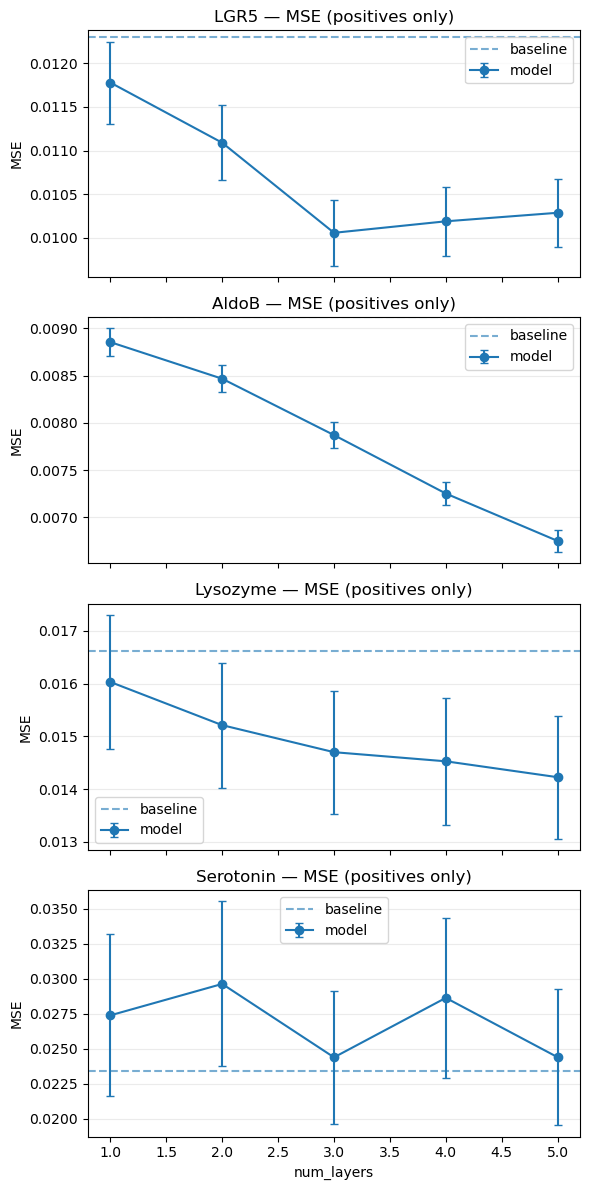

In [9]:
# ---- choose markers to plot ----
selected_marker_names = ["LGR5", "AldoB", "Lysozyme", "Serotonin"]  # <-- change to your markers
name_to_idx = {n: i for i, n in enumerate(marker_names)}
selected_idx = [name_to_idx[n] for n in selected_marker_names]

# ---- MSE vs num_layers ----
n_sel = len(selected_idx)
fig, axes = plt.subplots(n_sel, 1, figsize=(6, 3*n_sel), sharex=True)

if n_sel == 1:
    axes = [axes]

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    ax.errorbar(
        num_layers,
        all_mse_model[:, mi],
        yerr=all_sem_mse_model[:, mi],
        fmt='-o',
        capsize=3,
        label="model"
    )

    # baseline reference line
    ax.axhline(all_mse_base[mi], linestyle='--', alpha=0.6, label="baseline")

    ax.set_ylabel("MSE")
    ax.set_title(f"{mname} — MSE (positives only)")
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("num_layers")
plt.tight_layout()
plt.show()





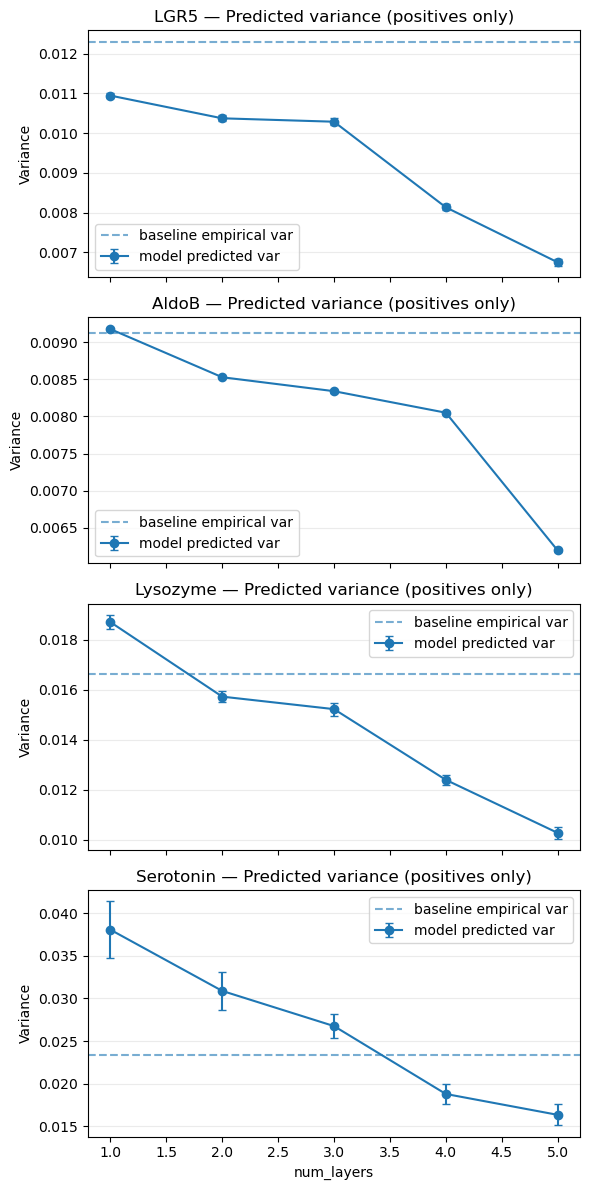

In [10]:
n_sel = len(selected_idx)
fig, axes = plt.subplots(n_sel, 1, figsize=(6, 3*n_sel), sharex=True)

if n_sel == 1:
    axes = [axes]

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    ax.errorbar(
        num_layers,
        all_var_model[:, mi],
        yerr=all_sem_var_model[:, mi],
        fmt='-o',
        capsize=3,
        label="model predicted var"
    )

    # baseline empirical variance
    ax.axhline(all_var_base[mi], linestyle='--', alpha=0.6,
               label="baseline empirical var")

    ax.set_ylabel("Variance")
    ax.set_title(f"{mname} — Predicted variance (positives only)")
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("num_layers")
plt.tight_layout()
plt.show()


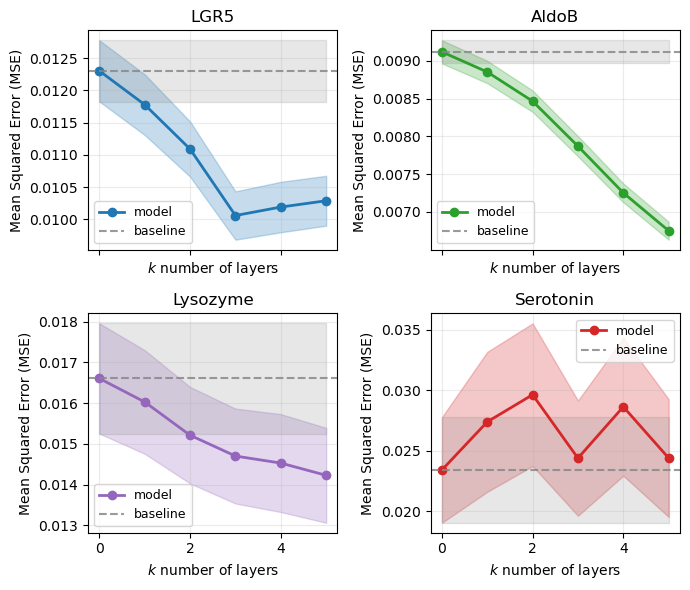

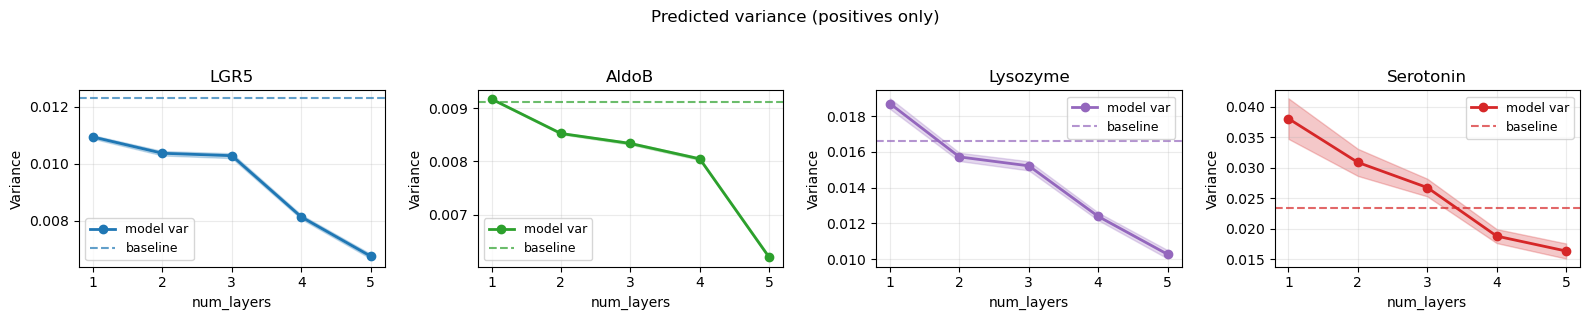

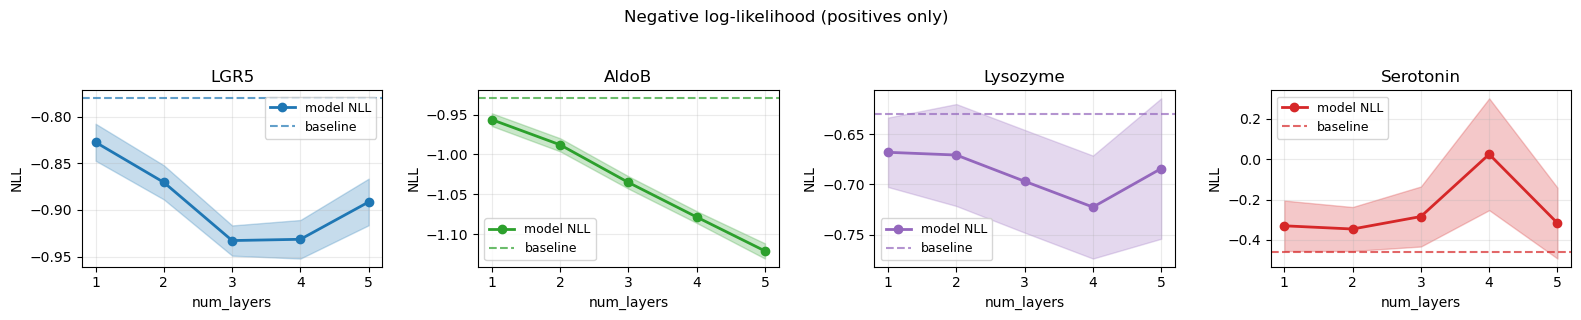

In [11]:
plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

marker_colors = {
    "LGR5":      "#1f77b4",
    "AldoB":     "#2ca02c",
    "Serotonin": "#d62728",
    "Lysozyme":  "#9467bd",
}

baseline_color = "#888888"


def get_marker_color(name):
    return marker_colors.get(name, "#333333")  # fallback dark gray


# plot MSE on 2x2 grid
n_sel = len(selected_idx)

fig, axes = plt.subplots(2, 2, figsize=(7, 6), sharex=True)
axes = axes.ravel()  # flatten grid → easy loop

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    c = get_marker_color(mname)

    y = all_mse_model[:, mi]
    s = all_sem_mse_model[:, mi]

    # prepend baseline as k=0 point
    y = np.concatenate(([all_mse_base[mi]], y))
    s = np.concatenate(([all_sem_mse_base[mi]], s))
    x = np.concatenate(([0], num_layers))

    # model curve + band
    ax.plot(x, y, '-o', linewidth=2, color=c, label="model")
    ax.fill_between(x, y - s, y + s, color=c, alpha=0.25)

    # baseline horizontal band (grey)
    y0 = all_mse_base[mi]
    s0 = all_sem_mse_base[mi]

    ax.axhline(y0, linestyle='--', color=baseline_color,
               alpha=0.85, label="baseline")

    ax.fill_between(
        x,
        y0 - s0,
        y0 + s0,
        color=baseline_color,
        alpha=0.2
    )

    ax.set_title(mname)
    ax.set_ylabel("Mean Squared Error (MSE)")
    ax.set_xlabel("$k$ number of layers")
    ax.legend(fontsize=9)

# hide unused panels if <4 markers
for ax in axes[n_sel:]:
    ax.set_visible(False)

plt.tight_layout()

plt.show()



# plot varinace
n_sel = len(selected_idx)
fig, axes = plt.subplots(1, n_sel, figsize=(4*n_sel, 3), sharex=True)

if n_sel == 1:
    axes = [axes]

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    c = get_marker_color(mname)
    y = all_var_model[:, mi]
    s = all_sem_var_model[:, mi]

    ax.plot(num_layers, y, '-o', linewidth=2, color=c, label="model var")
    ax.fill_between(num_layers, y - s, y + s, color=c, alpha=0.25)

    ax.axhline(all_var_base[mi], linestyle='--', linewidth=1.5,
               color=c, alpha=0.7, label="baseline")

    ax.set_title(mname)
    ax.set_ylabel("Variance")
    ax.set_xlabel("num_layers")
    ax.legend(fontsize=9)

fig.suptitle("Predicted variance (positives only)", y=1.05)
plt.tight_layout()
plt.show()


# plot NLL
n_sel = len(selected_idx)
fig, axes = plt.subplots(1, n_sel, figsize=(4*n_sel, 3), sharex=True)

if n_sel == 1:
    axes = [axes]

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    c = get_marker_color(mname)
    y = all_nll_model[:, mi]
    s = all_sem_nll_model[:, mi]

    ax.plot(num_layers, y, '-o', linewidth=2, color=c, label="model NLL")
    ax.fill_between(num_layers, y - s, y + s, color=c, alpha=0.25)

    ax.axhline(all_nll_base[mi], linestyle='--', linewidth=1.5,
               color=c, alpha=0.7, label="baseline")

    ax.set_title(mname)
    ax.set_ylabel("NLL")
    ax.set_xlabel("num_layers")
    ax.legend(fontsize=9)

fig.suptitle("Negative log-likelihood (positives only)", y=1.05)
plt.tight_layout()
plt.show()
